In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0



        MNIST DIGIT RECOGNITION — CNN

[1] Loading MNIST dataset...
    Train samples  : 60000
    Test  samples  : 10000
    Image shape    : (28, 28)  (28x28 grayscale)
    Classes        : 0 to 9


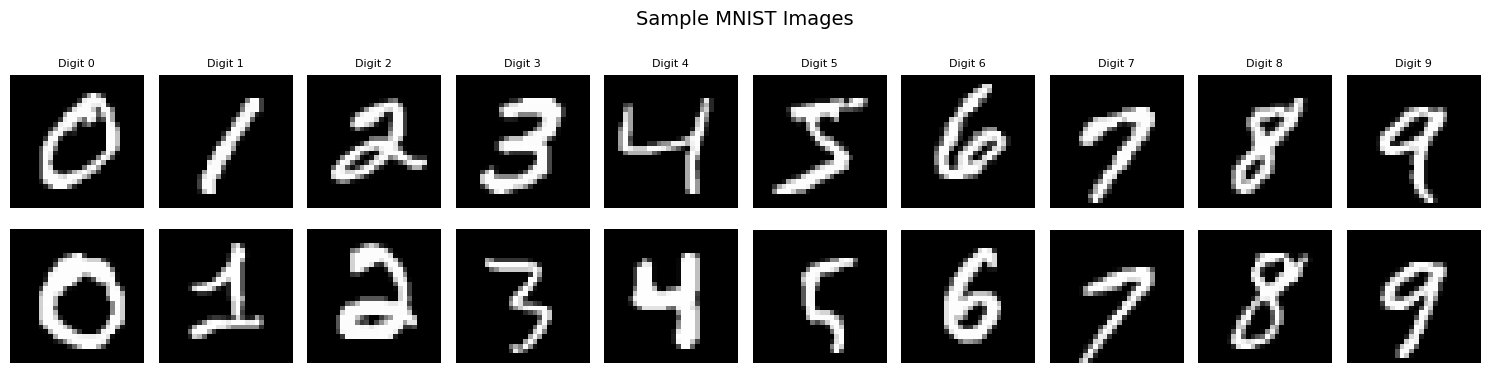

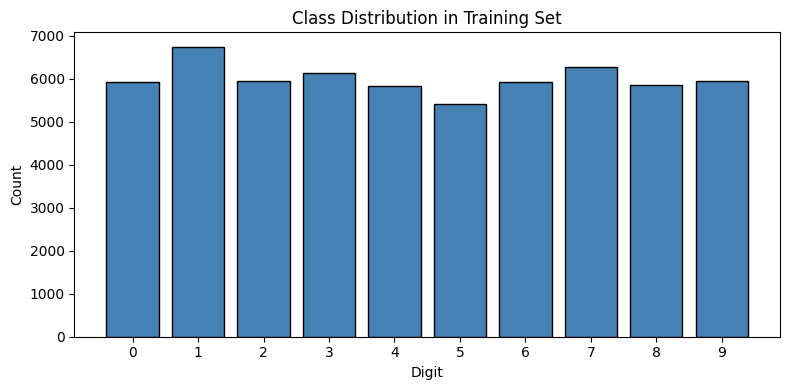

    EDA plots saved.


In [ ]:
print("\n" + "=" * 55)
print("        MNIST DIGIT RECOGNITION — CNN")
print("=" * 55)

print("\n[1] Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"    Train samples  : {X_train.shape[0]}")
print(f"    Test  samples  : {X_test.shape[0]}")
print(f"    Image shape    : {X_train.shape[1:]}  (28x28 grayscale)")
print(f"    Classes        : 0 to 9")

# EDA — Sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle("Sample MNIST Images", fontsize=14)
for digit in range(10):
    idx  = np.where(y_train == digit)[0][0]
    idx2 = np.where(y_train == digit)[0][5]
    axes[0, digit].imshow(X_train[idx],  cmap='gray')
    axes[1, digit].imshow(X_train[idx2], cmap='gray')
    axes[0, digit].set_title(f"Digit {digit}", fontsize=8)
    for row in [0, 1]:
        axes[row, digit].axis('off')
plt.tight_layout()
plt.savefig("sample_digits.png", dpi=100)
plt.show()

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.title("Class Distribution in Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.xticks(range(10))
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=100)
plt.show()
print("    EDA plots saved.")

In [ ]:
print("\n[2] Preprocessing...")

# Normalize pixel values: 0-255 → 0.0-1.0
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Reshape for CNN: (samples, 28, 28) → (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# One-Hot Encode labels: 5 → [0,0,0,0,0,1,0,0,0,0]
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print(f"    X_train shape  : {X_train.shape}")
print(f"    X_test  shape  : {X_test.shape}")
print(f"    y_train shape  : {y_train_ohe.shape}  (one-hot encoded)")


[2] Preprocessing...
    X_train shape  : (60000, 28, 28, 1)
    X_test  shape  : (10000, 28, 28, 1)
    y_train shape  : (60000, 10)  (one-hot encoded)


In [ ]:
print("\n[3] Building CNN Model...")

model = models.Sequential([

    # --- Block 1 ---
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Block 2 ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Fully Connected Head ---
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 output classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


[3] Building CNN Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
print("\n[4] Training CNN with Epochs...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train_ohe,
    epochs=15,
    batch_size=128,
    validation_split=0.1,       # 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)


[4] Training CNN with Epochs...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 276s 631ms/step - accuracy: 0.8750 - loss: 0.4099 - val_accuracy: 0.2490 - val_loss: 2.3396
Epoch 2/15
309/422 ━━━━━━━━━━━━━━━━━━━━ 1:08 610ms/step - accuracy: 0.9781 - loss: 0.0737


[5] Detailed Evaluation...

    Best Model -> Random Forest (95.17%)

    Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       399
           1       0.97      0.98      0.98       456
           2       0.92      0.94      0.93       386
           3       0.95      0.92      0.93       415
           4       0.94      0.95      0.95       389
           5       0.97      0.96      0.96       355
           6       0.97      0.97      0.97       394
           7       0.97      0.95      0.96       419
           8       0.95      0.91      0.93       384
           9       0.91      0.95      0.93       403

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



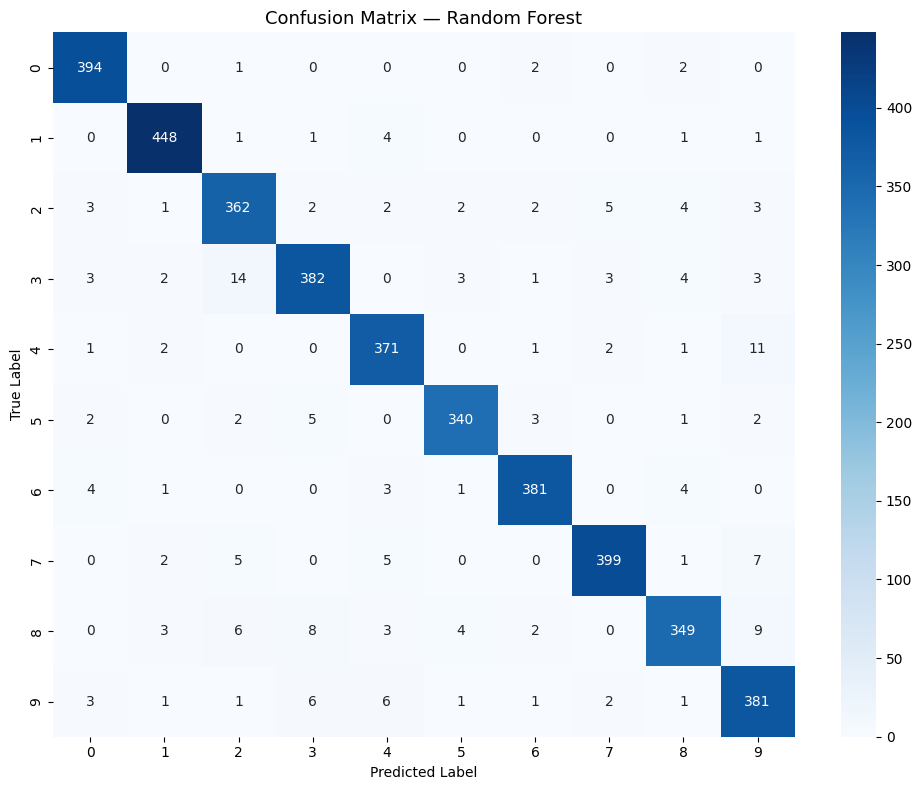

In [ ]:
print("\n[5] Plotting Training History...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_history.png", dpi=100)
plt.show()
print("    Saved -> training_history.png")

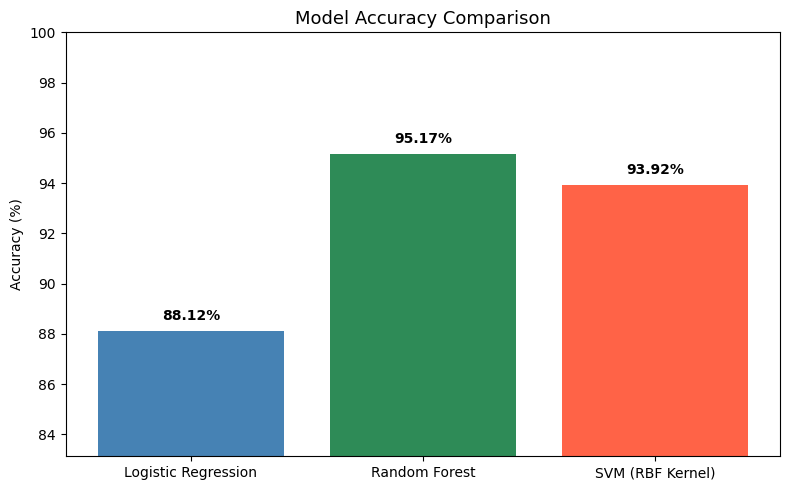

In [ ]:
print("\n[6] Evaluating on Test Set...")

test_loss, test_acc = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"\n    Test Loss     : {test_loss:.4f}")
print(f"    Test Accuracy : {test_acc * 100:.2f}%")



[7] Visual Predictions on Random Samples...


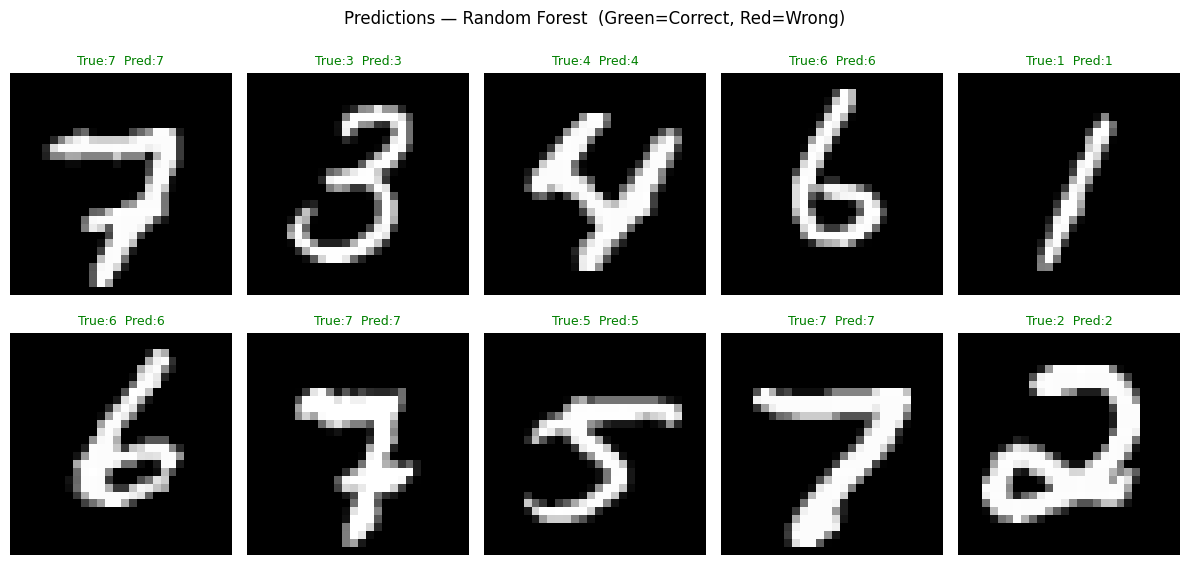

In [ ]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("\n    Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix — CNN", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()
print("    Saved -> confusion_matrix.png")


                   FINAL SUMMARY
  Logistic Regression       -> 88.12%
  Random Forest             -> 95.17%
  SVM (RBF Kernel)          -> 93.92%

  Best Model : Random Forest
  Accuracy   : 95.17%

Case Study Completed Successfully!


In [ ]:
print("\n[8] Visualizing Sample Predictions...")

sample_idx = np.random.choice(len(X_test), 15, replace=False)
fig, axes  = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle("CNN Predictions  (Green = Correct | Red = Wrong)", fontsize=13)
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    pred  = y_pred[idx]
    true  = y_test[idx]
    conf  = y_pred_probs[idx][pred] * 100
    color = 'green' if pred == true else 'red'
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"True:{true}  Pred:{pred}\n{conf:.1f}% conf",
                      color=color, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("predictions.png", dpi=100)
plt.show()
print("    Saved -> predictions.png")

In [ ]:
print("\n[9] Visualizing Feature Maps...")

feature_model = models.Model(
    inputs=model.input,
    outputs=model.layers[0].output   # Output of first Conv2D layer
)
sample_img    = X_test[0:1]          # Pick one image
feature_maps  = feature_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("Feature Maps — First Conv Layer (32 filters)", fontsize=13)
axes = axes.flatten()
for i in range(32):
    axes[i].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[i].set_title(f"Filter {i+1}", fontsize=7)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("feature_maps.png", dpi=100)
plt.show()
print("    Saved -> feature_maps.png")

In [ ]:
model.save("mnist_cnn_model.h5")
print("\n    Model saved -> mnist_cnn_model.h5")


# ── 14. FINAL SUMMARY ───────────────────────────────────────
print("\n" + "=" * 55)
print("                   FINAL SUMMARY")
print("=" * 55)
print(f"  Model          : CNN (Convolutional Neural Network)")
print(f"  Dataset        : MNIST (60,000 train / 10,000 test)")
print(f"  Epochs trained : {len(history.history['loss'])}")
print(f"  Batch size     : 128")
print(f"  Test Accuracy  : {test_acc * 100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print("=" * 55)
print("\nCase Study Completed Successfully!")